# 01 · Validate & clean the ticks — bad data is the #1 source of fake edges

> ⏱️ **~20 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 2 · Validate &nbsp;·&nbsp; 🧩 **Feeds:** ALL editions (every backtest is only as honest as this gate)
>
> 🎯 **Goal:** Decide which ticks to trust. Drop the physically-impossible, keep-and-flag the merely weird.
>
> 🔑 **The one thing to remember:** Cleaning is *decisions*, made using only the past. Drop the impossible; never delete a weird-but-real bar.

## Notebook 01 in one breath

> **Where we are.** Notebook 00 imported the raw ticks into Parquet *faithfully* — bugs and all. This
> notebook is the Python mirror of **Phase 2 — Validate & Clean** (`pipeline/validate_data.py`). A
> single bad tick (a price of 0, a crossed spread, a duplicated row) can manufacture a profit out of
> thin air in a backtest. Cleaning is a **hard gate** before we build anything.

**What you'll learn:**
1. A reusable **data-quality checklist** for any time series.
2. The crucial distinction between **drop** (clearly broken) and **keep + flag** (weird but real).
3. The **spread-realism trap** — our single biggest cost-modeling hazard, hiding in plain sight.
4. **Gaps & coverage** — weekends, missing days, and why "missing" is not always "broken".
5. A first encounter with **lookahead / data leakage**, the career-ending bug.

> 🧭 **Golden rule of cleaning.** Cleaning is a sequence of *decisions*, and every decision must use
> **only information available at that tick** — never the future. We also never edit the imported file
> in place: we write a new `*_clean.parquet` and a report, so the choice is auditable.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import duckdb                 # streams Parquet/CSV without loading it all into RAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
DATA = ROOT / "data"
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from pipeline import ...` works (the real Layer-1 code)
con  = duckdb.connect()       # one in-memory DuckDB connection we reuse all notebook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("data dir  :", DATA)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
data dir  : /Users/tokyotechies/Workspace/KEM/dquants/data


## Step 1 · Load the imported (not-yet-clean) ticks

We work on 2026 BTC — the smallest year — so checks run in well under a second. This is the *output of
Phase 1*: faithfully converted, but unvalidated.

In [2]:
raw_pq = DATA / "processed" / "ticks_btcusd_2026.parquet"   # imported, NOT cleaned
n = con.sql(f"SELECT count(*) FROM read_parquet('{raw_pq.as_posix()}')").fetchone()[0]
print(f"imported ticks: {n:,}")
con.sql(f"SELECT * FROM read_parquet('{raw_pq.as_posix()}') LIMIT 5").df()

imported ticks: 14,951,271


,ts,bid,ask,mid,spread,flags
0,2026-01-01 00:00:05.830,"87,510.5","87,523.1","87,516.8",12.6,6
1,2026-01-01 00:00:07.529,"87,503","87,515.6","87,509.3",12.6,6
2,2026-01-01 00:00:07.551,"87,509.5","87,522.1","87,515.8",12.6,6
3,2026-01-01 00:00:07.590,"87,513.9","87,526.5","87,520.2",12.6,6
4,2026-01-01 00:00:10.707,"87,505.8","87,518.4","87,512.1",12.6,6


## Step 2 · The data-quality checklist

Run these on *any* new dataset, in this order. Each one is a single streaming SQL pass. We classify
every row, then decide its fate.

| # | Check | Verdict | Why |
|---|-------|---------|-----|
| a | `bid<=0 or ask<=0` (non-positive price) | **DROP** | impossible; a feed glitch |
| b | `spread<0` (ask below bid — "crossed") | **DROP** | impossible in a real book |
| c | exact-duplicate row (same ts **and** bid **and** ask as prior) | **DROP** | double-export artifact |
| d | round-trip **spike** (jumps >1% then instantly reverts) | **DROP** | single-tick glitch |
| e | **ts collision** (distinct ticks share one millisecond) | **KEEP + flag** | real sub-ms ticks |
| f | `spread=0` (bid == ask) | **KEEP + flag** | rare but legal |
| g | wide spread (> 5× median) | **KEEP + flag** | real volatility, not an error |

Let's count each on the real 2026 data.

In [3]:
q = con.sql(f"""
    WITH ordered AS (
        SELECT ts, bid, ask, mid, spread,
               lag(ts)  OVER () AS pts, lag(bid) OVER () AS pbid, lag(ask) OVER () AS pask,
               lag(mid) OVER () AS pmid, lead(mid) OVER () AS nmid
        FROM read_parquet('{raw_pq.as_posix()}')
    )
    SELECT
        count(*) AS total,
        count(*) FILTER (WHERE bid<=0 OR ask<=0)                                     AS a_bad_px,
        count(*) FILTER (WHERE spread<0)                                             AS b_neg_spread,
        count(*) FILTER (WHERE pts=ts AND bid=pbid AND ask=pask)                     AS c_exact_dup,
        count(*) FILTER (WHERE pmid IS NOT NULL AND nmid IS NOT NULL AND pmid>0
                          AND abs(mid-pmid)/pmid > 0.01
                          AND abs(nmid-pmid)/pmid < 0.005)                           AS d_spike,
        count(*) FILTER (WHERE pts=ts AND NOT (bid=pbid AND ask=pask))               AS e_ts_collision,
        count(*) FILTER (WHERE spread=0)                                             AS f_zero_spread
    FROM ordered
""").df().T
q.columns = ["count"]
q

,count
total,14951271
a_bad_px,0
b_neg_spread,0
c_exact_dup,24328
d_spike,0
e_ts_collision,534
f_zero_spread,0


> 📘 **Concept — drop vs keep+flag.** The novice instinct is to delete anything "weird". That is how
> you *destroy real signal*. A wide spread during a crash isn't an error — it's the most important bar
> of the week. A timestamp collision isn't a duplicate — it's two genuine sub-millisecond ticks. We
> only **drop** the physically impossible (price ≤ 0, crossed spread, exact byte-duplicates, instant
> spikes that revert). Everything else we **keep and write to a report** so a human can judge. *When in
> doubt, flag — don't delete.*

## Step 3 · What the production validator actually decided

`pipeline/validate_data.py` ran exactly these rules across all three years and wrote a JSON + Markdown
report per year into `reports/`. Let's load the real reports rather than re-deriving them — this is the
audit trail.

In [4]:
import json
rows = []
for year in (2024, 2025, 2026):
    r = json.loads((ROOT / "reports" / f"validation_btcusd_{year}.json").read_text())
    rows.append({
        "year": year,
        "in":        r["total_in"],
        "kept":      r["total_kept"],
        "dropped":   r["total_in"] - r["total_kept"],
        "drop_dup":  r["dropped"]["exact_dup"],
        "drop_spike":r["dropped"]["spike"],
        "flag_collision": r["flagged"]["ts_collision"],
        "passed":    r["passed"],
    })
pd.DataFrame(rows).set_index("year")

,in,kept,dropped,drop_dup,drop_spike,flag_collision,passed
year,,,,,,,
2024,83350554,83264725,85829,85828,1,85867,True
2025,148657447,148534200,123247,123247,0,14285,True
2026,14951271,14926943,24328,24328,0,534,True


Note how few rows are actually dropped (a fraction of a percent) — but each one could have created a
fake trade. Note also `passed=True`: the validator re-checks the *clean* output and confirms zero
residual bad prices / crossed spreads / exact dups.

## Step 4 · The spread-realism trap (read this twice)

Spread is the dominant scalping cost. Here is the trap that can quietly invalidate an entire backtest:
**spread behaves completely differently across years on this feed.** Let's measure median and p99
spread per year from the *clean* files.

In [5]:
rows = []
for year in (2024, 2025, 2026):
    p = (DATA / "processed" / f"ticks_btcusd_{year}_clean.parquet").as_posix()
    s = con.sql(f"""
        SELECT round(median(spread),2) med, round(quantile_cont(spread,0.99),2) p99,
               round(max(spread),2) mx
        FROM read_parquet('{p}')
    """).fetchone()
    rows.append({"year": year, "median_spread": s[0], "p99_spread": s[1], "max_spread": s[2],
                 "p99/median": round(s[1]/s[0], 2)})
spread_by_year = pd.DataFrame(rows).set_index("year")
spread_by_year

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,median_spread,p99_spread,max_spread,p99/median
year,,,,
2024,20.29,58.34,180.24,2.88
2025,20.16,20.31,306.41,1.01
2026,12.6,12.6,18.9,1


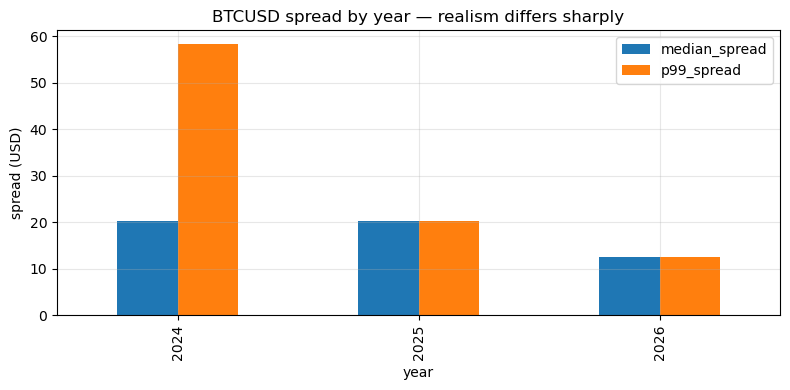

In [6]:
ax = spread_by_year[["median_spread", "p99_spread"]].plot(kind="bar", figsize=(8,4))
ax.set_ylabel("spread (USD)"); ax.set_title("BTCUSD spread by year — realism differs sharply")
plt.tight_layout(); plt.show()

- **2024** has *realistic, variable* spread: it widens ~3× under stress (p99 ≫ median).
- **2025** is nearly **flat** (p99 ≈ median).
- **2026** is **perfectly fixed** (median == p99 == max).

> ⚠️ **Why this can ruin you.** If you calibrate your cost model on 2025/2026 (flat spread), your
> backtest will **understate the cost of trading during volatility** — exactly when scalpers get hurt.
> The honest move: calibrate costs on **2024** (variable), or model spread conservatively. This single
> insight is worth more than most "strategy ideas". See the memory note `btcusd-data-quirks`.

## Step 5 · Gaps & coverage — "missing" is not always "broken"

A scalper lives and dies by *when* the market is liquid. Let's look at how many ticks arrive per day,
and find the biggest time-gaps between consecutive ticks, on clean 2026.

In [7]:
clean_2026 = (DATA / "processed" / "ticks_btcusd_2026_clean.parquet").as_posix()

# Ticks per day, and the biggest gaps between consecutive ticks.
per_day = con.sql(f"""
    SELECT ts::DATE AS day, count(*) AS ticks
    FROM read_parquet('{clean_2026}') GROUP BY 1 ORDER BY 1
""").df()
gaps = con.sql(f"""
    WITH g AS (SELECT ts, lag(ts) OVER () AS pts,
                      date_part('epoch', ts - lag(ts) OVER ()) AS gap_s
               FROM read_parquet('{clean_2026}'))
    SELECT pts::VARCHAR AS gap_start, ts::VARCHAR AS gap_end, round(gap_s,0) AS gap_seconds
    FROM g WHERE gap_s IS NOT NULL ORDER BY gap_s DESC LIMIT 5
""").df()

print(f"days with data : {len(per_day)}")
print(f"ticks/day      : min {per_day.ticks.min():,}  median {int(per_day.ticks.median()):,}  max {per_day.ticks.max():,}")
print("\nbiggest gaps:")
gaps

days with data : 160
ticks/day      : min 23,557  median 83,698  max 412,336

biggest gaps:


,gap_start,gap_end,gap_seconds
0,2026-01-25 07:00:54.038,2026-01-25 07:04:42.346,228
1,2026-01-18 06:00:58.228,2026-01-18 06:04:05.815,188
2,2026-05-17 06:00:54.992,2026-05-17 06:04:00.916,186
3,2026-03-01 06:00:57.658,2026-03-01 06:04:03.526,186
4,2026-03-29 06:00:59.43,2026-03-29 06:04:05.29,186


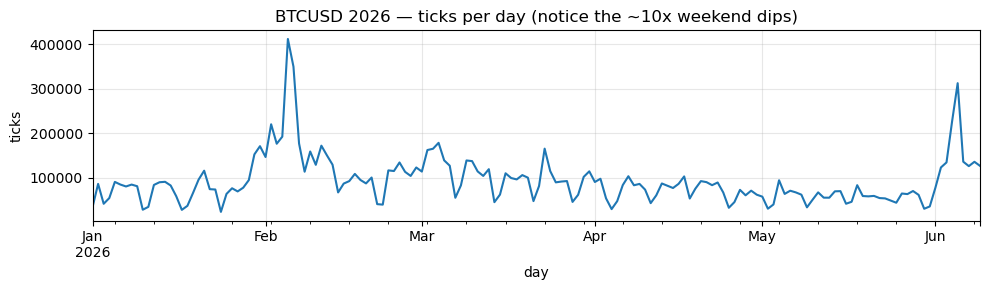

In [8]:
ax = per_day.set_index("day")["ticks"].plot(figsize=(10,3))
ax.set_title("BTCUSD 2026 — ticks per day (notice the ~10x weekend dips)")
ax.set_ylabel("ticks"); plt.tight_layout(); plt.show()

The dips aren't bugs — **weekends have ~10× lower BTC CFD liquidity**, and a few multi-hour gaps are
broker maintenance windows. (2025 is even missing 3 whole calendar days.)

> 📘 **Concept — event-time vs calendar-time.** Because ticks only exist when the market moves, our
> data is *event-time*: there's simply no row for a dead minute or a closed weekend. In notebook 02
> we'll build bars that inherit this — a bar exists only for a minute that had ≥1 tick. Indicators
> therefore run on the **bar sequence**, not on wall-clock time. Any backtest spanning these dates
> must *tolerate* the gaps rather than assume continuous time.

## Step 6 · First contact with the lookahead trap

We'll meet this monster again and again, so meet it now. **Lookahead (a.k.a. data leakage)** is letting
any information from *after* time `t` influence a decision made *at* `t`.

A concrete cleaning example: suppose a tick is missing and you "fix" it with
`df["mid"].fillna(method="bfill")` (**backward**-fill). That copies a *future* price backward into the
present. Your backtest now "knows" where price went — and will look brilliant and be worthless.

In [9]:
demo = pd.DataFrame({"t": range(6), "mid": [100, 101, None, None, 104, 105]})
demo["BAD_bfill (uses future)"]  = demo["mid"].bfill()     # leaks 104 backward into t=2,3
demo["OK_ffill (uses past)"]     = demo["mid"].ffill()     # only carries the last known value
demo

,t,mid,BAD_bfill (uses future),OK_ffill (uses past)
0,0,100,100,100
1,1,101,101,101
2,2,NaN,104,101
3,3,NaN,104,101
4,4,104,104,104
5,5,105,105,105


The `bfill` column put **104** (a future value) at t=2. If a feature used that, the model would see the
future. The `ffill` column only ever carries forward the *last known* value — causal and safe. Our
pipeline avoids the issue entirely by **not inventing ticks**: missing means missing.

> 🧠 **Carry this with you:** every feature at bar `t` may use only data `≤ t`. Labels (what we
> predict) are the *only* thing allowed to look forward. We'll enforce this mechanically in notebook 03
> and exploit it deliberately in notebook 04.

## 🎯 Your turn

1. **Validate gold.** XAU is imported but **not yet cleaned**. Run the Step 2 checklist on
   `ticks_xauusd_2026.parquet`. Any crossed spreads or exact duplicates? (This is real, unblazed
   territory — you'd be doing Phase 2 for gold.)
2. **Gold's spread realism.** Repeat Step 4 for XAU. Is gold's spread flat or variable by year?
3. **Coverage of gold.** Gold *closes on weekends* (unlike BTC). Re-run Step 5 on a XAU clean-or-raw
   file — do you see a clean weekly rhythm of missing days?
4. Read `reports/validation_btcusd_2024.md` (the human-readable report the validator wrote). Which
   single number would you most want to double-check before trusting a 2024 backtest?

➡️ **Next:** notebook **02** — turn this clean tick firehose into M1/M3 **bars**.